# Ximenez: Model (New)

# Set Up

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import sys
sys.path.append('../../local_lib/')
from narrative_model import NarrativeModel

In [23]:
sns.set_theme(style='white')
px_template = 'plotly_white'

# Data

In [24]:
src_id = "ximenez"
n_chunks = 60
CHUNK = pd.read_csv(f"{src_id}-CHUNK-{n_chunks}.csv").set_index('chunk_num')
TFIDF = pd.read_csv(f"{src_id}-TFIDF-{n_chunks}.csv").set_index('chunk_num')

# Model

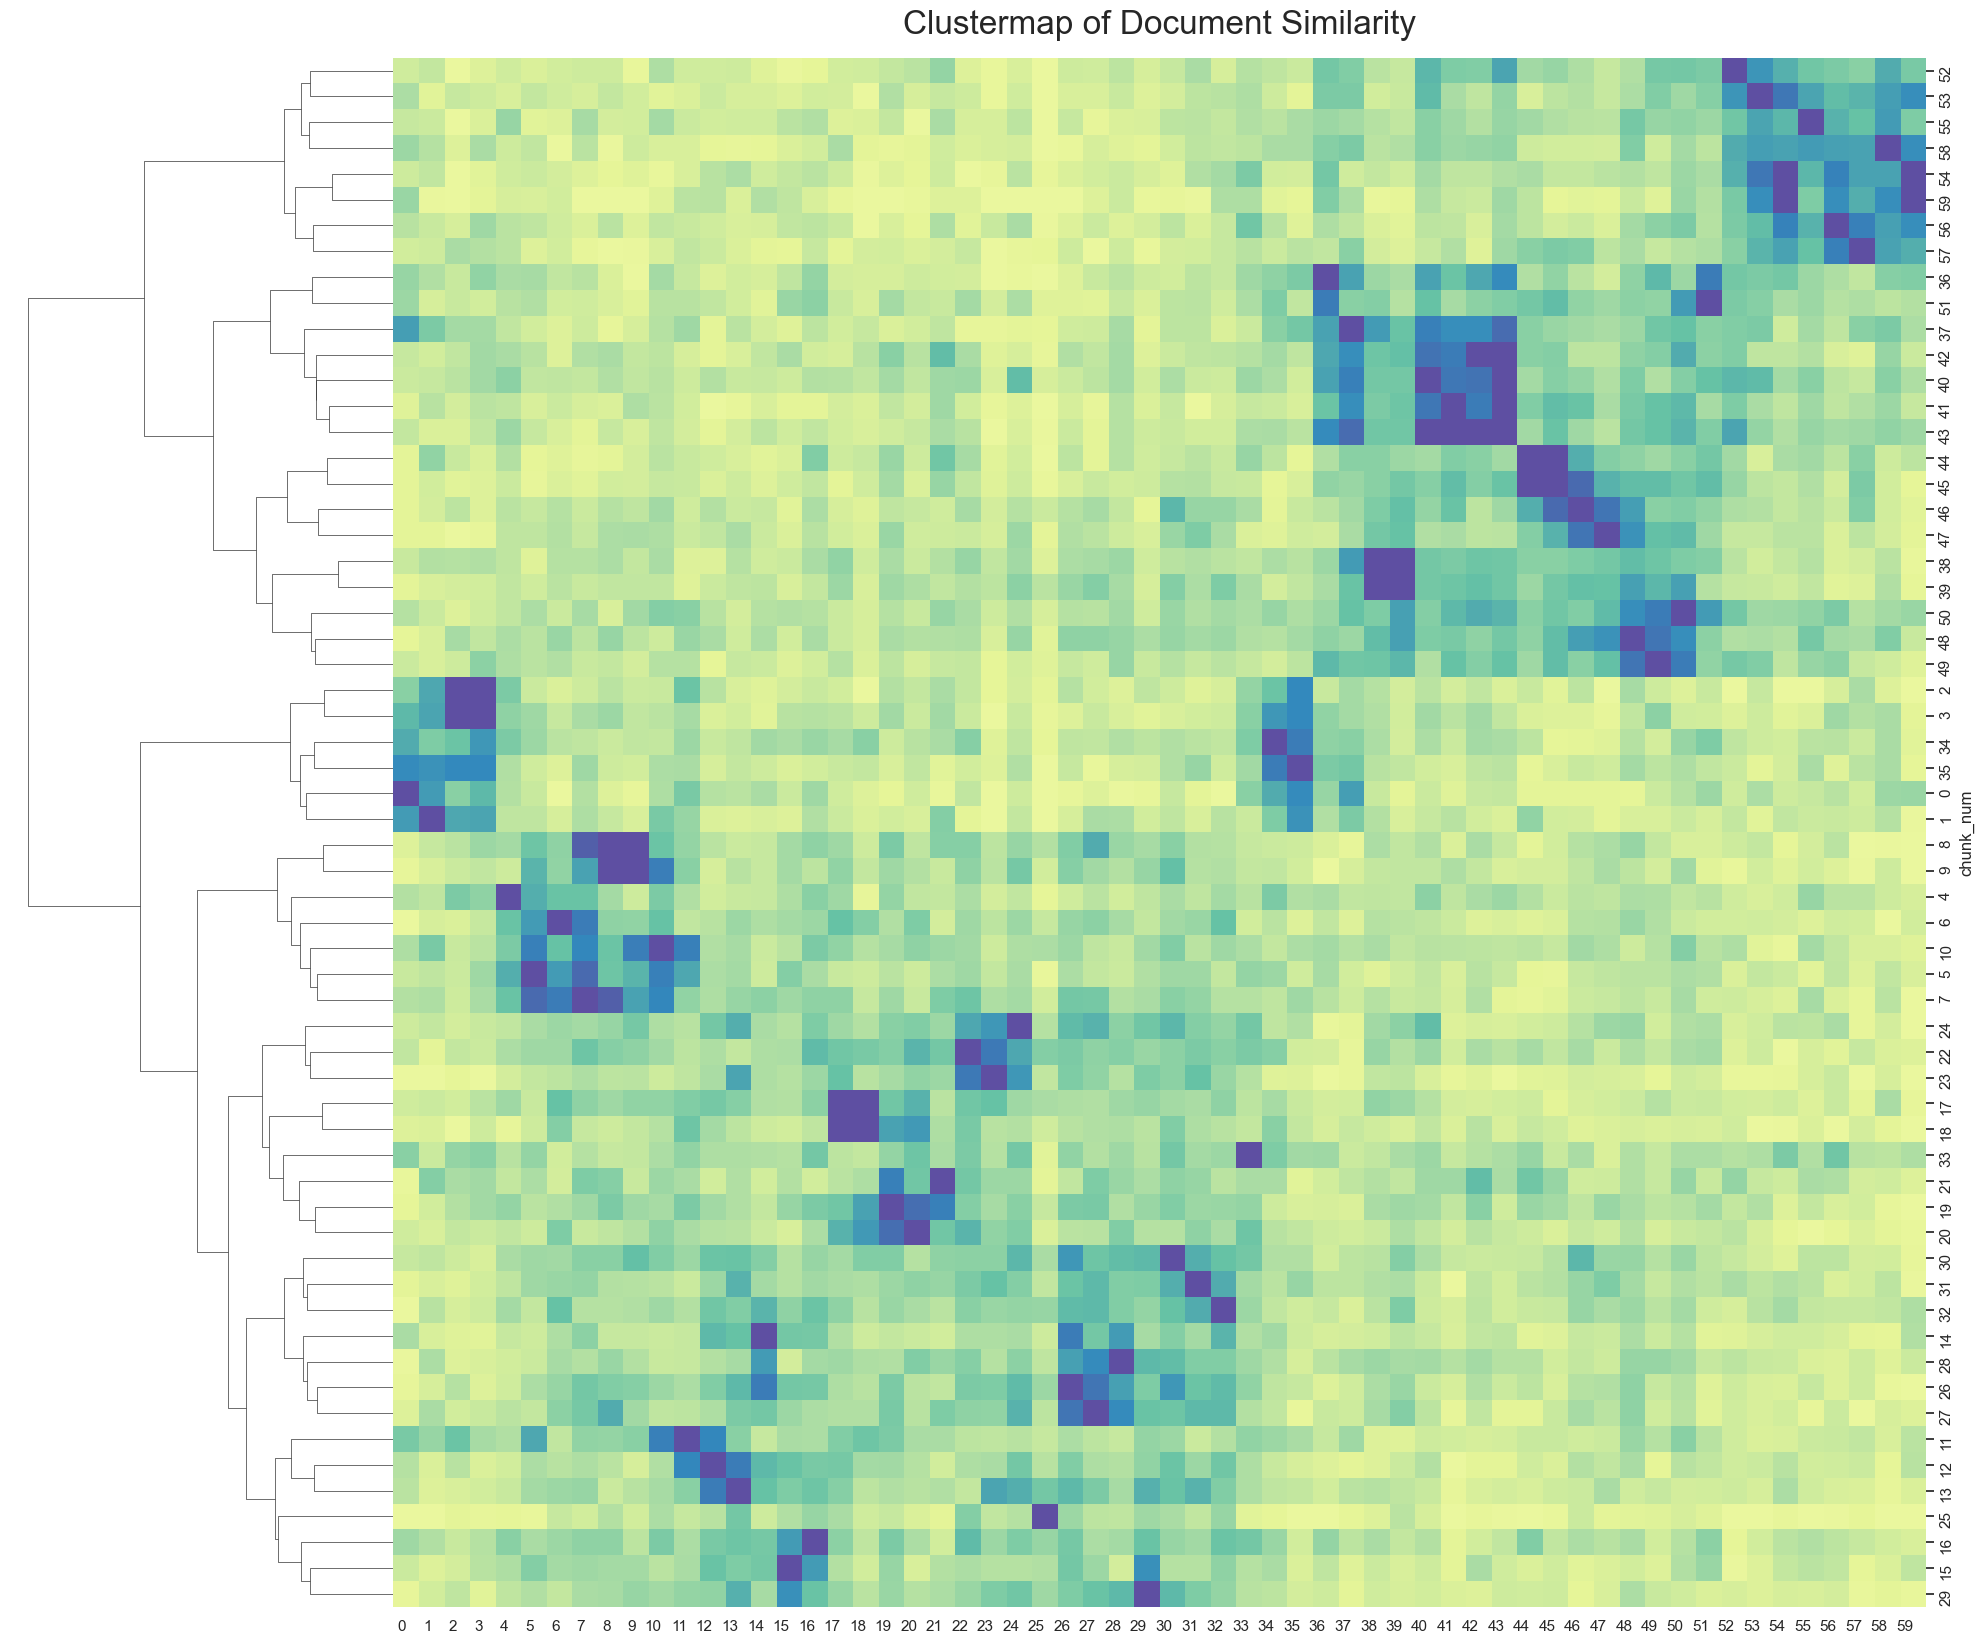

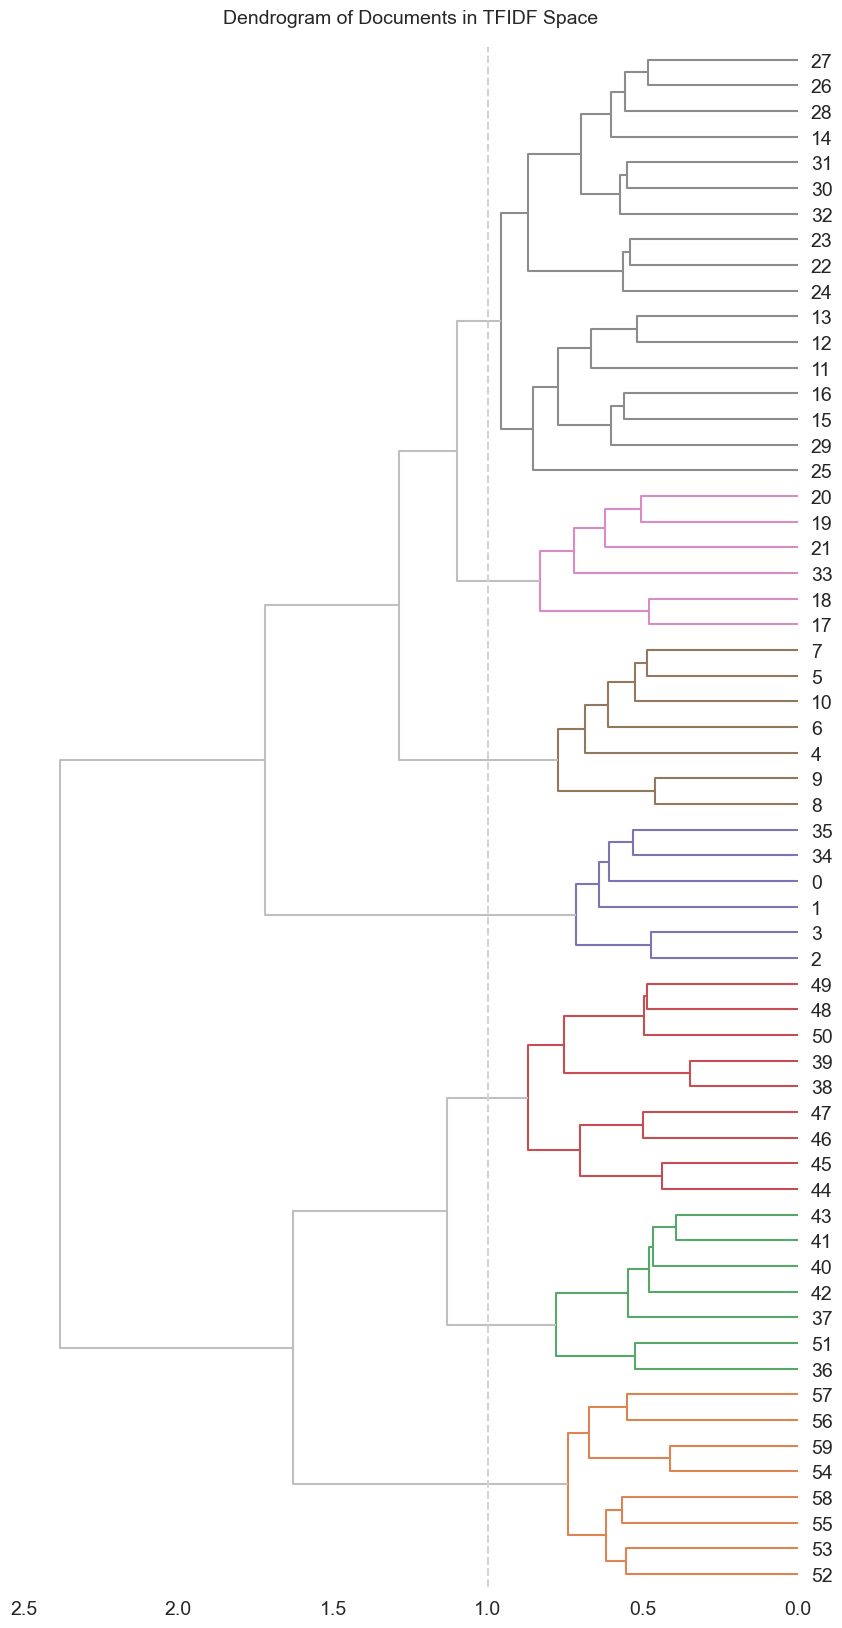

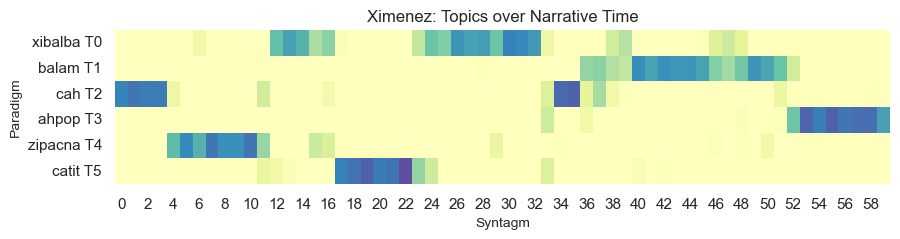

In [25]:
model = NarrativeModel(src_id, CHUNK, TFIDF)
model.run()

# Explore PCA

In [26]:
label_col = 'hac_label'
X0 = model.CHUNK.join(model.PCAX).join(model.CLUSTER, on=label_col)

In [27]:
def plot_pca(x, y):
    px.scatter(X0, x, y,
        text=X0.index,
        height=850, width=950,
        color=X0.gloss,
        size=[1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box',
    ).show()

    quantile = .99
    A = model.LOADINGS.loc[np.abs(model.LOADINGS[x]) >= np.abs(model.LOADINGS[x]).quantile(quantile), x]
    B = model.LOADINGS.loc[np.abs(model.LOADINGS[y]) >= np.abs(model.LOADINGS[y]).quantile(quantile), y]
    C = pd.concat([A, B], axis=1).index

In [28]:
plot_pca(0, 1)

In [29]:
plot_pca(1, 2)

In [30]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='gloss',
           color='gloss',
           template=px_template,
           height=400, width=600,
           title=f'PC {comp_id}').show()

for i in range(model.n_pca_comps):
    comp_box(i)